# Frontiers in Graph Neural Networks
## Graph Neural Networks Tutorial

本 Notebook 对应 Slides: **05_Frontiers in Graph neural networks.pdf**

这份笔记不是只把 GCN / GraphSAGE / GAT 逐个罗列一遍，而是试图回答更有意思的问题：

1. 为什么图比序列和图像更难建模？
2. message passing 到底是一种什么计算范式？
3. 聚合函数为什么是 GNN 的核心，而不是实现细节？
4. GCN 为什么既优雅又有限？oversmoothing 到底在“平滑”什么？
5. GraphSAGE、GAT、virtual node、Laplacian PE 各自在解决什么瓶颈？
6. Graph Transformer 真的是“把 Transformer 搬到图上”这么简单吗？

---

### 你会在这里看到什么？

- 更深入的公式解释，不只停留在直觉层面
- CPU 友好的 toy experiments，让你直接看到 GNN 的行为
- 从零写的核心算子，尽量少依赖封装
- 少量 `torch` 训练示例，用来把原理和实践接起来

### 目录

1. 为什么图难：排列不变性与关系建模
2. 图表示与任务
3. Message Passing 的统一视角
4. Aggregation 为什么是核心
5. GCN：图上的低通滤波器
6. Oversmoothing 现象
7. GraphSAGE：采样与归纳泛化
8. GAT：让邻居权重变得可学习
9. 从零训练一个小型 GCN
10. Graph-level readout 与 virtual node
11. Graph Transformer 与 Laplacian positional encoding
12. Graph Transformer vs Message Passing：更系统的比较
13. 限制与前沿：1-WL、oversquashing、graph foundation models

In [13]:
# 如果环境里还没有这些包，可以先取消注释下一行。
# %pip install networkx scikit-learn

import math
import random
from collections import defaultdict

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.set_printoptions(precision=3, sci_mode=False)
np.set_printoptions(precision=3, suppress=True)
plt.style.use('seaborn-v0_8-whitegrid')


def normalized_adj_numpy(A, add_self_loops=True):
    A = np.array(A, dtype=np.float32)
    if add_self_loops:
        A = A + np.eye(A.shape[0], dtype=np.float32)
    deg = A.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.clip(deg, 1e-8, None)))
    return D_inv_sqrt @ A @ D_inv_sqrt


def normalized_adj_torch(A, add_self_loops=True):
    A = A.clone().float()
    if add_self_loops:
        A = A + torch.eye(A.shape[0])
    deg = A.sum(dim=1)
    D_inv_sqrt = torch.diag(torch.pow(torch.clamp(deg, min=1e-8), -0.5))
    return D_inv_sqrt @ A @ D_inv_sqrt


def draw_graph(G, node_colors=None, ax=None, title=None, pos=None):
    if ax is None:
        ax = plt.gca()
    if pos is None:
        pos = nx.spring_layout(G, seed=SEED)
    if node_colors is None:
        node_colors = '#4C72B0'
    nx.draw_networkx(
        G, pos=pos, ax=ax,
        node_color=node_colors,
        edge_color='#999999',
        with_labels=True,
        node_size=500,
        font_size=9,
    )
    ax.set_title(title or '')
    ax.axis('off')
    return pos


print('torch version   =', torch.__version__)
print('networkx version=', nx.__version__)

torch version   = 2.5.1
networkx version= 3.2.1


---
## 1. 为什么图难：排列不变性与关系建模

Slides 开头提到图结构系统无处不在，但真正麻烦的点不是“有节点和边”，而是：

- 图没有天然的一维顺序，也没有二维卷积那样的规则网格
- 节点度数不固定，每个节点的邻居数都可能不同
- 图的局部结构和全局结构同时重要
- 同一个图可以有无数种节点编号方式，但它们应该表示同一个对象

如果你把序列、图像、图放在一起比较，会更清楚图为什么难：

- 序列的归纳偏置是“相邻 token 在一条线上”，位置天然存在
- 图像的归纳偏置是“局部 patch 在二维平面上平移等价”，卷积核可以共享
- 图的归纳偏置则是“对象之间靠关系连接”，但这些关系既不规则，也没有固定坐标系

这意味着：在图上建模时，我们不能依赖节点编号本身，而必须依赖 **结构关系**。这最后一点尤其关键。设图表示成邻接矩阵 $A$、节点特征矩阵 $X$。如果我们用一个置换矩阵 $\Pi$ 重新编号节点，那么图会变成：

$$
A' = \Pi A \Pi^\top, \qquad X' = \Pi X
$$

一个合理的图神经网络应该满足 **置换等变性**（node-level tasks）：

$$
f(A', X') = \Pi f(A, X)
$$

而对 graph-level readout 来说，则需要 **置换不变性**：

$$
g(A', X') = g(A, X)
$$

也就是说：**改编号可以改输出的排列，但不能改图本身的意义**。这和序列模型、图像模型很不一样。

再往深一层看，图学习几乎总在同时处理两种问题：

1. **表示局部关系**：一个节点和它的一跳、二跳邻域发生了什么
2. **汇聚全局语义**：整个图的社团结构、桥接节点、长程依赖是什么

而这两者往往彼此冲突。层数太浅，看不到远端结构；层数太深，又容易出现 oversmoothing 或 oversquashing。后面你会发现，很多 GNN 变体本质上都在调这个张力。

Permutation equivariance for neighbor sum: True
original operator output:
 [[10. 12.]
 [ 4.  6.]
 [ 8. 10.]
 [12. 14.]
 [ 6.  8.]]
permuted operator output:
 [[ 8. 10.]
 [10. 12.]
 [ 6.  8.]
 [ 4.  6.]
 [12. 14.]]


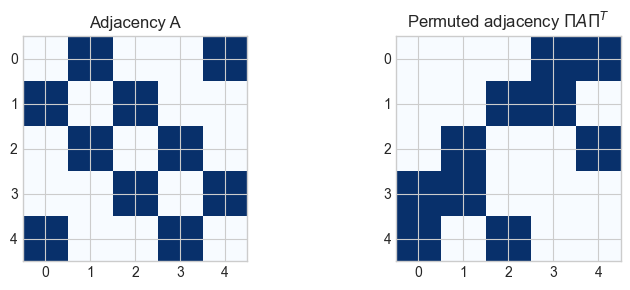

In [14]:
G = nx.cycle_graph(5)
A = nx.to_numpy_array(G, dtype=np.float32)
X = np.arange(10, dtype=np.float32).reshape(5, 2)

perm = np.array([2, 0, 4, 1, 3])
Pi = np.eye(len(perm), dtype=np.float32)[perm]
A_perm = Pi @ A @ Pi.T
X_perm = Pi @ X

# 一个最简单的“图算子”：邻居求和
lhs = A_perm @ X_perm
rhs = Pi @ (A @ X)

print('Permutation equivariance for neighbor sum:', np.allclose(lhs, rhs))
print('original operator output:\n', A @ X)
print('permuted operator output:\n', lhs)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(A, cmap='Blues')
axes[0].set_title('Adjacency A')
axes[1].imshow(A_perm, cmap='Blues')
axes[1].set_title('Permuted adjacency $\\Pi A \\Pi^T$')
plt.tight_layout()
plt.show()

---
## 2. 图表示与任务

Slides 用 $\mathcal{G} = (V, A, X)$ 表示图，这里可以补得更完整一点：

- $V$: 节点集合
- $E$: 边集合
- $A \in \mathbb{R}^{n \times n}$: 邻接矩阵或带权邻接矩阵
- $X \in \mathbb{R}^{n \times d}$: 节点特征
- 可选的边特征 $E_{ij}$、图特征 $u$

常见任务可以统一成三类：

1. node-level：每个节点预测一个标签或实数
2. edge-level / link prediction：判断一条边是否存在，或预测边属性
3. graph-level：对整个图做分类、回归、生成

一个很好的思考框架是：**图神经网络到底是在“节点上做预测”，还是在“结构上传播信息”**？

答案通常是后者。节点级任务只是最终 supervision 的落点，真正让 GNN 和 MLP 拉开差距的是：它会显式利用图上的关系结构。

---
## 3. Message Passing 的统一视角

Slides 中最重要的一页，其实不是某个具体模型，而是 general GNN / graph network 的三步：

1. 在边上产生 message
2. 在节点上 aggregate message
3. 用 aggregate 结果更新节点状态

这可以写成 message passing neural network (MPNN) 的统一形式：

$$
m_{ij}^{(k)} = \phi_m\big(h_i^{(k)}, h_j^{(k)}, e_{ij}\big)
$$

$$
M_i^{(k)} = \bigoplus_{j \in \mathcal{N}(i)} m_{ij}^{(k)}
$$

$$
h_i^{(k+1)} = \phi_u\big(h_i^{(k)}, M_i^{(k)}\big)
$$

其中：

- $h_i^{(k)}$ 是第 $k$ 层节点 $i$ 的表示
- $\phi_m$ 是 message function
- $\bigoplus$ 是 permutation-invariant aggregation，比如 sum / mean / max
- $\phi_u$ 是 update function

如果再加 graph-level readout，则是：

$$
h_{\mathcal{G}} = \operatorname{READOUT}\big(\{h_i^{(K)}\}_{i \in V}\big)
$$

这套写法很强，因为它把 GCN、GraphSAGE、GAT、graph transformer 的很多变体都放进了同一个视角里。

更值得记住的是：**message passing 其实定义了一种计算边界**。做完 $K$ 层以后，节点 $i$ 的表示最多只能依赖它的 $K$-hop 邻域：

$$
h_i^{(K)} = \Psi^{(K)}\big(\{h_j^{(0)} : j \in \mathcal{N}^{K}(i)\}\big)
$$

这里的 $\Psi^{(K)}$ 不是简单函数，而是把前面每层的 message、aggregate、update 全部复合起来后的结果。这个式子告诉你两件很重要的事：

- GNN 天然有很强的 **locality bias**，它更擅长先看局部模式，再逐层扩展感受野
- 如果任务真的依赖很远的节点，单纯堆深 message passing 往往会遇到信息衰减或瓶颈

所以从算法味道上看，message passing 很像一种“可学习的局部动态规划”：

- 边负责传递局部证据
- 节点负责把邻域证据压缩成一个固定维表示
- 多层堆叠负责把局部证据逐步传播成更大范围的结构语义

这也是为什么 GNN 既像卷积，又不像卷积。像，是因为它也在局部共享参数；不像，是因为它的“局部邻域”不是规则窗口，而是由图结构决定。

In [15]:
# 一个手写的单层 message passing 示例
A_toy = np.array([
    [0, 1, 1, 0],
    [1, 0, 1, 0],
    [1, 1, 0, 1],
    [0, 0, 1, 0],
], dtype=np.float32)

H = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
    [2.0, 0.0],
], dtype=np.float32)

W_msg = np.array([
    [0.7, -0.2, 0.5, 0.1],
    [-0.1, 0.6, 0.2, 0.8],
], dtype=np.float32)
W_upd = np.array([
    [0.8, 0.0, 0.3, -0.2],
    [0.1, 0.9, -0.4, 0.6],
], dtype=np.float32)


def message_fn(h_i, h_j):
    x = np.concatenate([h_i, h_j])
    return np.tanh(W_msg @ x)


def update_fn(h_i, m_i):
    x = np.concatenate([h_i, m_i])
    return np.tanh(W_upd @ x)


messages = defaultdict(list)
for i in range(A_toy.shape[0]):
    for j in range(A_toy.shape[1]):
        if A_toy[i, j] == 1:
            messages[i].append(message_fn(H[i], H[j]))

M = np.stack([np.sum(messages[i], axis=0) for i in range(A_toy.shape[0])])
H_next = np.stack([update_fn(H[i], M[i]) for i in range(A_toy.shape[0])])

print('node features before:\n', H)
print('\naggregated messages:\n', M)
print('\nnode features after one MP step:\n', H_next)

node features before:
 [[1. 0.]
 [0. 1.]
 [1. 1.]
 [2. 0.]]

aggregated messages:
 [[1.526 1.321]
 [0.671 1.586]
 [2.204 2.182]
 [0.964 0.664]]

node features after one MP step:
 [[ 0.759  0.275]
 [-0.115  0.919]
 [ 0.772  0.891]
 [ 0.942  0.21 ]]


---
## 4. Aggregation 为什么是核心

Slides 单独列出 aggregation 不是偶然的。对 GNN 来说，aggregation 决定了两件事：

1. 你怎样压缩一个可变大小邻域
2. 你能保留多少结构信息

常见聚合有：

- sum
- mean
- max
- median
- LSTM / sort-based aggregation
- generalized mean
- sampling-based aggregation

为什么 sum 特别重要？因为它通常更接近 injective map。直觉上：

- mean 容易把“多邻居”和“少邻居”平均成一样
- max 只保留极大值，容易丢掉计数信息
- sum 更容易保留多重集（multiset）差异

更严格一点说，节点邻域不是普通集合，而是 **multiset**。因为两个值一样的邻居出现两次和出现一次，语义通常不同。我们真正想编码的是：

$$
\mathcal{M}_i^{(k)} = \{\!\{ h_j^{(k)} : j \in \mathcal{N}(i) \}\!\}
$$

这里花括号上多一层强调，表示这是允许重复元素的多重集。aggregation 的本质，就是把这个多重集映射成一个定长向量：

$$
M_i^{(k)} = \operatorname{AGG}\big(\mathcal{M}_i^{(k)}\big)
$$

如果这个映射太粗糙，结构信息会在这一层直接丢失，后面再深也补不回来。

这就是为什么 aggregation 和 GNN 表达能力、1-WL 关系都很深。下面用一个很小的例子看一下。

In [16]:
neigh_A = np.array([[1.0, 0.0], [1.0, 0.0]])
neigh_B = np.array([[1.0, 0.0]])
neigh_C = np.array([[1.0, 0.0], [0.0, 1.0]])


def agg_stats(X):
    return {
        'sum': X.sum(axis=0),
        'mean': X.mean(axis=0),
        'max': X.max(axis=0),
    }


for name, X in [('A', neigh_A), ('B', neigh_B), ('C', neigh_C)]:
    stats = agg_stats(X)
    print(f'Neighborhood {name}:')
    print('  nodes =\n', X)
    print('  sum  =', stats['sum'])
    print('  mean =', stats['mean'])
    print('  max  =', stats['max'])
    print()

print('Observation: A and B have the same mean and max, but different sums.')

Neighborhood A:
  nodes =
 [[1. 0.]
 [1. 0.]]
  sum  = [2. 0.]
  mean = [1. 0.]
  max  = [1. 0.]

Neighborhood B:
  nodes =
 [[1. 0.]]
  sum  = [1. 0.]
  mean = [1. 0.]
  max  = [1. 0.]

Neighborhood C:
  nodes =
 [[1. 0.]
 [0. 1.]]
  sum  = [1. 1.]
  mean = [0.5 0.5]
  max  = [1. 1.]

Observation: A and B have the same mean and max, but different sums.


---
## 5. GCN：图上的低通滤波器

GCN 之所以经典，不只是因为它简单，而是因为它把“图卷积”写成了极其干净的线性代数形式。

最常见的 GCN layer 写成：

$$
H^{(k+1)} = \sigma\!\left(\hat{D}^{-1/2} \hat{A} \, \hat{D}^{-1/2} H^{(k)} W^{(k)}\right)
$$

其中：

$$
\hat{A} = A + I, \qquad \hat{D}_{ii} = \sum_j \hat{A}_{ij}
$$

这里有三个核心点：

1. **加 self-loop**：节点在聚合邻居时也保留自己
2. **对称归一化**：高连接度节点不会粗暴地主导传播
3. **共享线性变换**：每个节点都用同一组参数处理

如果先忽略非线性和权重，单看传播算子：

$$
S = \hat{D}^{-1/2} \hat{A} \hat{D}^{-1/2}
$$

那么 GCN 的核心动作其实就是：

$$
H \leftarrow S H
$$

也就是把每个节点的表示和邻域做一次归一化混合。一个更深的理解是：GCN 本质上像在图上做低通滤波（low-pass filtering）。

- 高频：相邻节点差异很大
- 低频：相邻节点特征比较平滑

为什么会这样？因为归一化拉普拉斯定义为：

$$
L_{\mathrm{sym}} = I - D^{-1/2} A D^{-1/2}
$$

而传播算子与它只差一个符号平移关系。若

$$
L_{\mathrm{sym}} = U \Lambda U^\top
$$

那么在谱域里，GCN 传播近似对应于对各个频率分量乘上某个系数。频率越高，通常越容易被压低；频率越低，越容易被保留。所以应用一次归一化邻接传播，就会让相邻节点的表示更接近一点；连续应用很多次，就会越来越平滑。

这也是 GCN 最迷人的地方：一个看上去像“邻居平均”的简单操作，背后其实带着图信号处理的谱解释。优点和缺点也来自同一个来源。

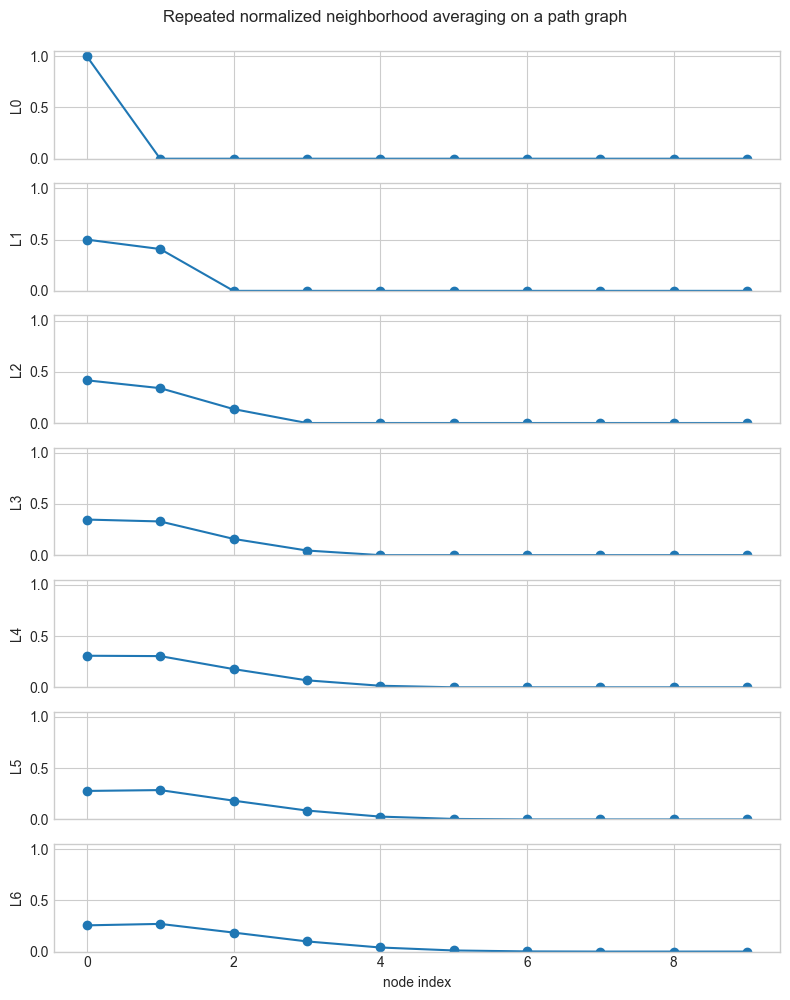

In [17]:
# 用 path graph 上的脉冲信号观察 GCN-style smoothing
G_path = nx.path_graph(10)
A_path = nx.to_numpy_array(G_path, dtype=np.float32)
S_path = normalized_adj_numpy(A_path)

H0 = np.zeros((10, 1), dtype=np.float32)
H0[0, 0] = 1.0

states = [H0.copy()]
H = H0.copy()
for _ in range(6):
    H = S_path @ H
    states.append(H.copy())

fig, axes = plt.subplots(len(states), 1, figsize=(8, 10), sharex=True)
for layer, (ax, H_layer) in enumerate(zip(axes, states)):
    ax.plot(H_layer[:, 0], marker='o')
    ax.set_ylabel(f'L{layer}')
    ax.set_ylim(0, 1.05)
axes[-1].set_xlabel('node index')
fig.suptitle('Repeated normalized neighborhood averaging on a path graph', y=0.995)
plt.tight_layout()
plt.show()

### Oversmoothing：GCN 的强项为什么会变成弱点？

如果我们不断应用类似 $S = \hat{D}^{-1/2} \hat{A} \hat{D}^{-1/2}$ 的传播，节点表示会逐渐落到图拉普拉斯的低频子空间里。

直观地看：

- 第 1 层：你和邻居变得更像
- 第 5 层：你和二跳、三跳邻居都更像
- 第 20 层：整张图里大量节点开始难以区分

这就是 **oversmoothing**：不是模型“训练坏了”，而是传播算子把节点表示洗得太平了。

如果把非线性和参数先拿掉，连续传播大致是在看：

$$
H^{(K)} \approx S^K H^{(0)}
$$

当 $K$ 很大时，很多图上的 $S^K$ 会把不同节点的表示推向一个低维、甚至接近 rank-1 的子空间。粗糙地说，最后每个节点都像是在重复同一份“图的平均信息”。

这里很容易和另一个概念混淆：

- **oversmoothing**：节点表示越来越像，区分度下降
- **oversquashing**：远处大量信息被压进固定维度向量，传不过来

两者都和深层传播有关，但不是同一个问题。oversmoothing 更像“全都混匀了”，oversquashing 更像“信息通道太窄了”。下面先在 Karate Club 图上看 oversmoothing 现象。

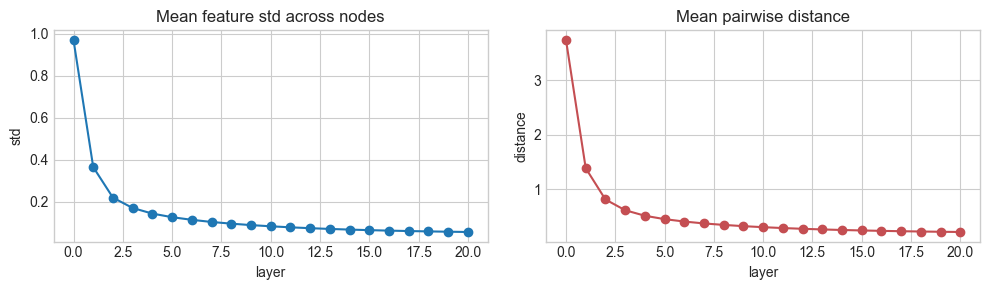

In [18]:
G_karate = nx.karate_club_graph()
A_karate = nx.to_numpy_array(G_karate, dtype=np.float32)
S_karate = normalized_adj_numpy(A_karate)

H = np.random.randn(G_karate.number_of_nodes(), 8).astype(np.float32)
variances = []
mean_pairwise_dist = []

for _ in range(21):
    variances.append(H.std(axis=0).mean())
    D = np.linalg.norm(H[:, None, :] - H[None, :, :], axis=-1)
    mean_pairwise_dist.append(D.mean())
    H = S_karate @ H

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(variances, marker='o')
axes[0].set_title('Mean feature std across nodes')
axes[0].set_xlabel('layer')
axes[0].set_ylabel('std')

axes[1].plot(mean_pairwise_dist, marker='o', color='#C44E52')
axes[1].set_title('Mean pairwise distance')
axes[1].set_xlabel('layer')
axes[1].set_ylabel('distance')
plt.tight_layout()
plt.show()

---
## 6. GraphSAGE：采样与归纳泛化

GCN 的一个典型限制是：它通常默认整张图都在训练图里，而且全邻域聚合在大图上很贵。

GraphSAGE 的核心思路是两个字：**sample**。

一个 mean-aggregator 版本可以写成：

$$
\bar{h}_{\mathcal{N}(i)}^{(k)} = \operatorname{MEAN}\big(\{ h_j^{(k)} : j \in \mathcal{N}(i) \}\big)
$$

$$
h_i^{(k+1)} = \sigma\!\left(W^{(k)} \cdot \big[h_i^{(k)} \Vert \bar{h}_{\mathcal{N}(i)}^{(k)}\big]\right)
$$

这里的关键改动是：

- 用 `concat(self, neighbor-agg)` 明确保留 self 信息
- 可以只采样固定数量邻居，而不是聚合全部邻居
- 更自然地支持 inductive setting：新节点来了，只要看到其邻域特征就能算 embedding

这在工业图、推荐系统、大规模知识图里很重要。

为什么采样这么重要？因为邻域会指数爆炸。假设每层都保留 $s_k$ 个邻居，那么一个两层 GraphSAGE 为了计算一个目标节点，通常只需要访问大约

$$
1 + s_1 + s_1 s_2
$$

个节点；而如果你不采样，在高度节点和大图上这个数会非常快地失控。

更重要的是，GraphSAGE 学的是一个 **邻域聚合函数**，而不是每个训练节点的专属 embedding。也就是说，它更像在学一个可迁移的规则：

- 给我一个节点自身特征
- 再给我它采样到的邻域特征
- 我就能算出这个节点的表示

这就是它比早期 transductive 方法更适合工业场景的地方。

In [19]:
# 在 star graph 上看看邻域采样如何改变 GraphSAGE 的输入
G_star = nx.star_graph(8)  # center=0
features_star = {i: np.array([i, (-1) ** i], dtype=np.float32) for i in G_star.nodes()}


def sample_neighbors(G, node, k):
    nbrs = list(G.neighbors(node))
    if len(nbrs) <= k:
        return nbrs
    return random.sample(nbrs, k)


def sage_mean_input(G, node, k=None):
    nbrs = list(G.neighbors(node)) if k is None else sample_neighbors(G, node, k)
    nbr_mean = np.mean([features_star[j] for j in nbrs], axis=0)
    return nbrs, np.concatenate([features_star[node], nbr_mean])


all_nbrs, full_vec = sage_mean_input(G_star, 0, k=None)
print('Full-neighborhood GraphSAGE input for node 0:')
print('  neighbors =', all_nbrs)
print('  concat(self, mean(neighbors)) =', full_vec)
print()

for trial in range(3):
    nbrs, sampled_vec = sage_mean_input(G_star, 0, k=3)
    print(f'Sampled run {trial + 1}: neighbors = {nbrs}, concat vector = {sampled_vec}')

Full-neighborhood GraphSAGE input for node 0:
  neighbors = [1, 2, 3, 4, 5, 6, 7, 8]
  concat(self, mean(neighbors)) = [0.  1.  4.5 0. ]

Sampled run 1: neighbors = [2, 1, 6], concat vector = [0.    1.    3.    0.333]
Sampled run 2: neighbors = [5, 2, 7], concat vector = [ 0.     1.     4.667 -0.333]
Sampled run 3: neighbors = [3, 6, 1], concat vector = [ 0.     1.     3.333 -0.333]


---
## 7. GAT：让邻居权重变得可学习

GCN 和 mean-GraphSAGE 都有一个默认前提：**邻居大体上同等重要**。这在很多图上太强了。

GAT 的核心是把“聚合谁、聚合多少”变成数据依赖的 attention：

$$
z_i = W h_i
$$

$$
e_{ij} = \operatorname{LeakyReLU}\big(a^\top [z_i \Vert z_j]\big)
$$

$$
\alpha_{ij} = \frac{\exp(e_{ij})}{\sum_{k \in \mathcal{N}(i)} \exp(e_{ik})}
$$

$$
h_i' = \sigma\!\left(\sum_{j \in \mathcal{N}(i)} \alpha_{ij} z_j\right)
$$

直觉上，GAT 在做的是：

- 不是“所有邻居平均一下”
- 而是“当前节点自己决定谁更值得听”

这在邻居质量差异大、边不可靠、异质图或局部 heterophily 场景下尤其有意思。

从传播类型上说，GCN 更像 **isotropic propagation**，即对不同邻居一视同仁；GAT 更像 **anisotropic propagation**，即沿不同边给不同强度的权重。这一步很关键，因为真实图里很多边的价值并不一样。

实际模型里通常还会用 multi-head attention：

$$
h_i' = \mathbin{\|}_{p=1}^{P} \sigma\!\left(\sum_{j \in \mathcal{N}(i)} \alpha_{ij}^{(p)} W^{(p)} h_j\right)
$$

这里不同 head 可以看不同类型的局部关系。有的 head 更像在找同质邻居，有的 head 更像在找桥接节点或异常连接。

当然，GAT 也不是免费午餐：attention 让模型更灵活，但也带来更高计算成本，而且 attention score 不一定就等于“真正因果上重要”。它是一个有用的可学习加权机制，但不该被神化成完美解释器。

In [20]:
# 一个 toy GAT attention 例子：中心节点会更偏向“相关”的邻居
h = {
    0: np.array([1.0, 1.0]),
    1: np.array([1.2, 0.9]),
    2: np.array([-1.0, -1.1]),
    3: np.array([0.1, 2.0]),
}
neighbors = [1, 2, 3]
W = np.eye(2, dtype=np.float32)
a = np.array([1.0, 0.5, 1.0, 0.5], dtype=np.float32)


def leaky_relu(x, negative_slope=0.2):
    return x if x >= 0 else negative_slope * x


z0 = W @ h[0]
scores = []
for j in neighbors:
    zj = W @ h[j]
    concat = np.concatenate([z0, zj])
    e_0j = leaky_relu(float(a @ concat))
    scores.append(e_0j)

scores = np.array(scores)
alpha = np.exp(scores) / np.exp(scores).sum()
weighted_sum = sum(w * (W @ h[j]) for w, j in zip(alpha, neighbors))
mean_sum = np.mean([W @ h[j] for j in neighbors], axis=0)

print('raw attention scores =', dict(zip(neighbors, scores.round(3))))
print('attention weights    =', dict(zip(neighbors, alpha.round(3))))
print('simple mean agg      =', mean_sum)
print('attention weighted   =', weighted_sum)

raw attention scores = {1: 3.15, 2: -0.01, 3: 2.6}
attention weights    = {1: 0.618, 2: 0.026, 3: 0.356}
simple mean agg      = [0.1 0.6]
attention weighted   = [0.75 1.24]


---
## 8. 从零训练一个小型 GCN：Karate Club 节点分类

只看 forward 还不够。下面我们做一个最小但完整的实验：

- 图：Zachary Karate Club
- 特征：one-hot node identity
- 监督：club label（两类）
- 模型：两层 GCN
- 实现：只用基础 `torch` 张量和优化器

这样能把 slides 里的 supervised node classification 真正落地。

这里故意用 one-hot 节点特征，是为了把重点放在“结构到底提供了什么信息”上。因为 one-hot 本身几乎没有可迁移语义，它更像是在说：每个节点先只有一个身份标记，模型必须靠图传播把这些离散身份变成带结构含义的 embedding。

epoch   0 | loss = 0.7183 | full-graph acc = 0.500
epoch  50 | loss = 0.0003 | full-graph acc = 0.971
epoch 100 | loss = 0.0029 | full-graph acc = 0.971
epoch 150 | loss = 0.0025 | full-graph acc = 0.971
epoch 200 | loss = 0.0024 | full-graph acc = 0.971
epoch 250 | loss = 0.0023 | full-graph acc = 0.971
epoch 300 | loss = 0.0022 | full-graph acc = 0.971


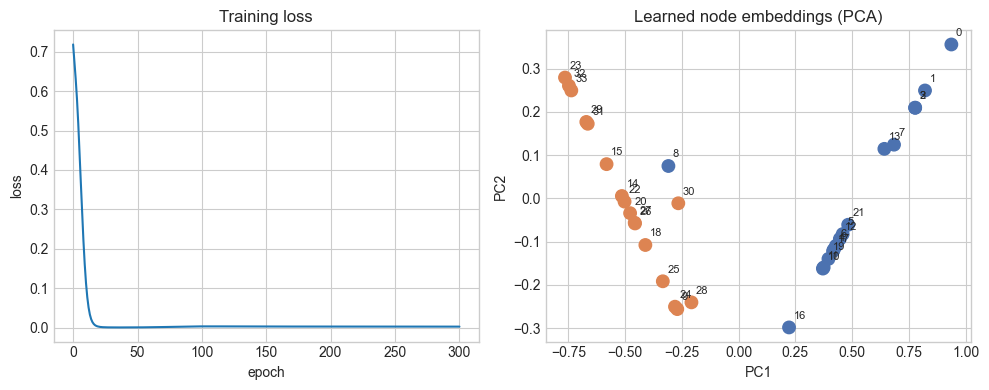

In [21]:
G = nx.karate_club_graph()
N = G.number_of_nodes()
A = torch.tensor(nx.to_numpy_array(G, dtype=np.float32))
S = normalized_adj_torch(A)
X = torch.eye(N)

y = torch.tensor([
    0 if G.nodes[i]['club'] == 'Mr. Hi' else 1
    for i in range(N)
], dtype=torch.long)

train_idx = torch.tensor([0, 1, 33, 32])

W1 = torch.nn.Parameter(torch.randn(N, 8) / math.sqrt(N))
W2 = torch.nn.Parameter(torch.randn(8, 2) / math.sqrt(8))
params = [W1, W2]
optimizer = torch.optim.Adam(params, lr=0.05, weight_decay=5e-4)


def gcn_forward(X, S, W1, W2):
    H1 = torch.relu(S @ X @ W1)
    logits = S @ H1 @ W2
    return logits, H1


loss_history = []
acc_history = []
for epoch in range(301):
    logits, H1 = gcn_forward(X, S, W1, W2)
    loss = F.cross_entropy(logits[train_idx], y[train_idx])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        pred = logits.argmax(dim=1)
        acc = (pred == y).float().mean().item()
    loss_history.append(loss.item())
    acc_history.append(acc)

    if epoch % 50 == 0:
        print(f'epoch {epoch:3d} | loss = {loss.item():.4f} | full-graph acc = {acc:.3f}')

with torch.no_grad():
    _, H1 = gcn_forward(X, S, W1, W2)
    emb_2d = PCA(n_components=2).fit_transform(H1.detach().numpy())
    colors = ['#4C72B0' if c == 0 else '#DD8452' for c in y.tolist()]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(loss_history)
axes[0].set_title('Training loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')

axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, s=80)
for i in range(N):
    axes[1].text(emb_2d[i, 0] + 0.02, emb_2d[i, 1] + 0.02, str(i), fontsize=8)
axes[1].set_title('Learned node embeddings (PCA)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.tight_layout()
plt.show()

### 这个实验真正说明了什么？

这个小实验最值得观察的，不是 accuracy 本身，而是：

- 即使只有极少标签，GCN 也能把结构信息传播出去
- one-hot 节点特征本身没有语义，但图结构提供了强 supervision shortcut
- embedding space 会把同社团节点往一起拉

从 message passing 视角看，这就是：**监督信号沿着图结构扩散，结构相近的节点被迫共享表示几何**。

你也可以把它理解成一种“可学习的 label propagation”。传统 label propagation 是直接在图上扩散标签；GCN 则是在扩散过程中同时学习一个表征空间，让“哪些节点应该相似”这件事由数据来共同决定。

---
## 9. Graph-level readout 与 virtual node

对于 graph classification / regression，最后必须把节点集合压成一个图表示。这一步通常是：

$$
h_{\mathcal{G}} = \operatorname{READOUT}\big(\{h_i\}_{i \in V}\big)
$$

常见 readout 有：

- sum pooling
- mean pooling
- max pooling
- attention pooling
- hierarchical pooling

这里有个常被忽略的点：**sum 和 mean 并不等价**。如果两张图节点特征分布相同但大小不同，mean pooling 可能完全分不出来。很多图分类任务里，图大小本身就是语义的一部分，所以 sum pooling 常常更有表达力。

Slides 里还提到 virtual node。它可以理解成一个“全局黑板”：

- 每个节点都和 virtual node 相连
- 节点可以把局部信息先写到 virtual node
- virtual node 再把全局上下文广播回去

这对稀疏图、长程依赖图很有帮助。

从图直径角度看也很直观。原来两个远端节点可能需要很多层才能互相影响；加了 virtual node 以后，很多路径都被压缩成“节点 $\rightarrow$ virtual node $\rightarrow$ 节点”的两跳通道。它确实会更粗暴，但能显著增强全局通信能力。

In [22]:
# sum vs mean pooling
X_small = np.ones((3, 1), dtype=np.float32)
X_large = np.ones((6, 1), dtype=np.float32)

print('mean pooling on 3-node graph =', X_small.mean(axis=0))
print('mean pooling on 6-node graph =', X_large.mean(axis=0))
print('sum pooling on 3-node graph  =', X_small.sum(axis=0))
print('sum pooling on 6-node graph  =', X_large.sum(axis=0))
print()

# virtual node demo: compare information propagation speed
G_line = nx.path_graph(6)
A_line = nx.to_numpy_array(G_line, dtype=np.float32)
S_line = normalized_adj_numpy(A_line)

G_virtual = G_line.copy()
virtual_id = 6
G_virtual.add_node(virtual_id)
for i in range(6):
    G_virtual.add_edge(i, virtual_id)
A_virtual = nx.to_numpy_array(G_virtual, dtype=np.float32)
S_virtual = normalized_adj_numpy(A_virtual)

signal_line = np.zeros((6, 1), dtype=np.float32)
signal_line[0, 0] = 1.0
signal_virtual = np.zeros((7, 1), dtype=np.float32)
signal_virtual[0, 0] = 1.0

for _ in range(2):
    signal_line = S_line @ signal_line
    signal_virtual = S_virtual @ signal_virtual

print('2-step signal at far end without virtual node =', float(signal_line[5, 0]))
print('2-step signal at far end with virtual node    =', float(signal_virtual[5, 0]))

mean pooling on 3-node graph = [1.]
mean pooling on 6-node graph = [1.]
sum pooling on 3-node graph  = [3.]
sum pooling on 6-node graph  = [6.]

2-step signal at far end without virtual node = 0.0
2-step signal at far end with virtual node    = 0.0476190485060215


---
## 10. Graph Transformer 与 Laplacian Positional Encoding

Slides 后半段最有意思的部分之一，是把 Transformer 搬到图上时“位置编码”该怎么定义。

序列里，position 很自然：第 1 个词、第 2 个词、第 3 个词……

图里没有天然顺序，所以要问一个更本质的问题：**什么才算图上的 position？**

如果你直接把普通 self-attention 用到节点集合上，而不注入任何结构信息，那么模型更像一个 set transformer，而不是 graph transformer。也就是说，它知道“有这些节点”，却不知道“这些节点之间怎样连接”。因此图上的 Transformer 往往必须额外注入结构偏置，比如：

- 邻接边或边类型 bias
- shortest-path distance / hop count
- random walk structural encoding
- Laplacian positional encoding

一种经典做法是用图拉普拉斯的特征向量作为位置编码。对无向图，归一化拉普拉斯可写成：

$$
L = I - D^{-1/2} A D^{-1/2}
$$

再做特征分解：

$$
L = U \Lambda U^\top
$$

其中 $U$ 的前几个非平凡特征向量，可以视为节点在图流形上的“频谱坐标”。

这个想法很美，因为它把“图上的位置”理解为：

- 谁和谁连通得更紧
- 谁处在图结构的相似区域
- 谁位于某种低频几何模式上

也就是说，**graph transformer 里的 position，不是线性序列位置，而是谱几何位置**。

把它放进 attention 的方式通常可以写成：

$$
\alpha_{ij} = \operatorname{softmax}_j\left(\frac{q_i^\top k_j}{\sqrt{d}} + b_{ij}\right)
$$

其中 $b_{ij}$ 可以来自图结构，例如最短路距离、边特征、Laplacian PE 诱导出的相对关系等。这样 attention 才不会忘记“谁和谁在图上真的靠近”。

当然，Laplacian PE 也有自己的细节问题，比如特征向量的符号不唯一、重根对应的特征子空间不唯一。这些都说明：图上的 position 不是一个完全解决好的问题，而正是 graph transformer 研究最有趣的部分之一。

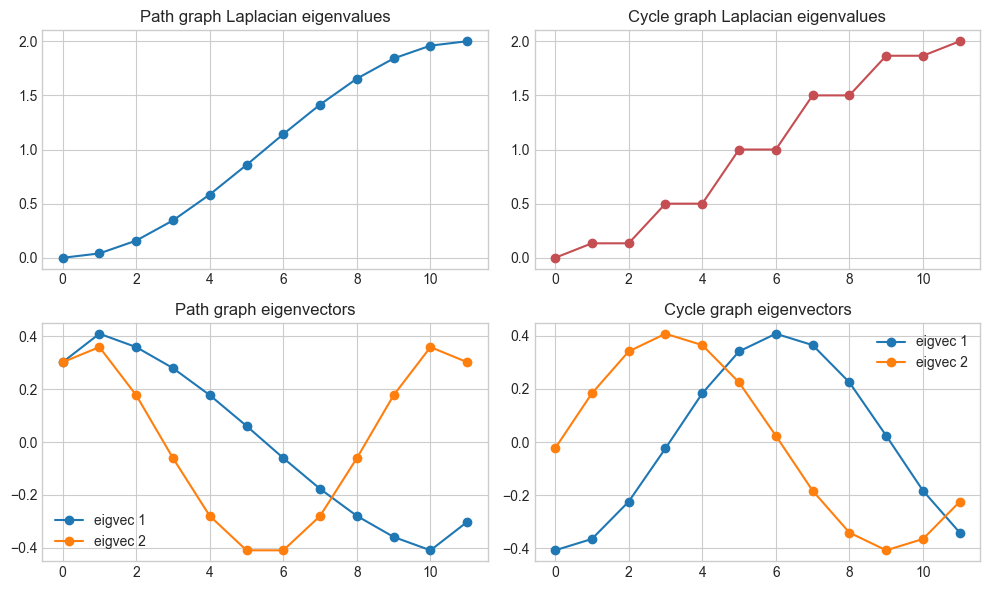

In [23]:
def normalized_laplacian(A):
    A = np.array(A, dtype=np.float32)
    D = np.diag(A.sum(axis=1))
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.clip(np.diag(D), 1e-8, None)))
    return np.eye(A.shape[0], dtype=np.float32) - D_inv_sqrt @ A @ D_inv_sqrt


G_path = nx.path_graph(12)
G_cycle = nx.cycle_graph(12)
L_path = normalized_laplacian(nx.to_numpy_array(G_path, dtype=np.float32))
L_cycle = normalized_laplacian(nx.to_numpy_array(G_cycle, dtype=np.float32))

vals_path, vecs_path = np.linalg.eigh(L_path)
vals_cycle, vecs_cycle = np.linalg.eigh(L_cycle)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes[0, 0].plot(vals_path, marker='o')
axes[0, 0].set_title('Path graph Laplacian eigenvalues')
axes[0, 1].plot(vals_cycle, marker='o', color='#C44E52')
axes[0, 1].set_title('Cycle graph Laplacian eigenvalues')

for k in [1, 2]:
    axes[1, 0].plot(vecs_path[:, k], marker='o', label=f'eigvec {k}')
    axes[1, 1].plot(vecs_cycle[:, k], marker='o', label=f'eigvec {k}')
axes[1, 0].set_title('Path graph eigenvectors')
axes[1, 1].set_title('Cycle graph eigenvectors')
axes[1, 0].legend()
axes[1, 1].legend()
plt.tight_layout()
plt.show()

---
## 11. Graph Transformer vs Message Passing：更系统的比较

到这里其实该正面回答一个问题了：**Graph Transformer 和传统的 message-passing GNN，到底是什么关系？是替代关系，还是包含关系？**

一个有用的判断是：它们不是简单的新旧替代，而是两种不同的归纳偏置。

传统 MPNN 的单层更新可以写成：

$$
h_i^{(k+1)} = \phi\left(h_i^{(k)}, \bigoplus_{j \in \mathcal{N}(i)} \psi\big(h_i^{(k)}, h_j^{(k)}, e_{ij}\big)\right)
$$

它默认只有局部邻域才能直接通信，所以结构偏置很强、局部性很自然、计算也通常更稀疏。

Graph Transformer 的单层更新更像：

$$
h_i^{(k+1)} = \sum_{j=1}^{n} \alpha_{ij} V h_j^{(k)}, \qquad \alpha_{ij} = \operatorname{softmax}_j\left(\frac{q_i^\top k_j}{\sqrt{d}} + b_{ij}\right)
$$

这里所有节点原则上都可以和所有节点直接交互，而结构信息往往通过 $b_{ij}$、边编码、距离编码、PE 等方式注入。

### 11.1 从归纳偏置看

- Message passing 默认相信“图上的局部邻域最重要”，因此天然偏向局部结构模式。
- Graph Transformer 默认相信“哪些节点该交互应由数据学习”，因此更灵活，但也更依赖设计良好的结构编码。

换句话说，MPNN 是 **structure-first**，Transformer 更接近 **interaction-first**。

### 11.2 从感受野看

- 一个 $K$ 层 MPNN 的节点表示，原则上最多依赖 $K$-hop 邻域。
- 一个全连接 Graph Transformer 在一层里就允许远距离节点直接通信。

这让 Transformer 在长程依赖上看起来更有优势，但代价是：如果没有足够强的结构 bias，它也可能把很多其实不该交互的节点混在一起。

### 11.3 从表达方式看

- MPNN 更像“沿边传播并逐层压缩邻域信息”。
- Graph Transformer 更像“在全局范围内学习一个动态的信息路由矩阵”。

如果把 attention 限制在邻居上，并加入边特征，那么很多 graph attention 变体其实仍然很接近 message passing。真正把两者拉开的是：**attention 是否允许非局部、非邻接的直接交互**。

### 11.4 从复杂度与可扩展性看

如果图有 $n$ 个节点、$m$ 条边，那么粗略地说：

- 稀疏 message passing 往往更接近 $O(m d)$
- 全连接 self-attention 往往更接近 $O(n^2 d)$

因此在大规模稀疏图上，经典 MPNN 往往仍然更实用。Graph Transformer 通常需要额外技巧来控成本，比如：

- sparse attention
- neighborhood attention
- subgraph batching
- token pruning / graph coarsening

### 11.5 从失败模式看

- MPNN 更容易遇到 oversmoothing 和 oversquashing，因为它的信息必须沿边逐层传。
- Graph Transformer 不太受固定 hop 限制，但可能更容易过度依赖位置编码、结构编码，或者在小数据场景下过拟合。

也就是说，Transformer 并不是“自动解决了 GNN 所有问题”，而是把问题从“层层传播瓶颈”转移成了“如何注入正确的结构先验”。

### 11.6 什么场景更偏向哪一类模型？

更偏向 message passing 的场景：

- 图很大而且很稀疏
- 局部化学键、局部拓扑模式特别重要
- 计算预算有限
- 任务更依赖局部归纳偏置

更偏向 graph transformer 的场景：

- 长程依赖明显
- 全局结构关系很关键
- 图规模中等，能承受更高计算
- 有比较成熟的结构编码可注入 attention

### 11.7 现实中更常见的答案：混合

现在很多强模型其实不是二选一，而是混合：

- 先用 message passing 提取局部结构模式
- 再用 transformer 聚合更远程、更全局的信息
- 或者把 attention 只放在子图、局部窗口、anchor nodes 上

所以更系统的结论不是“谁淘汰谁”，而是：

$$
\text{MPNN 擅长强局部归纳偏置，Graph Transformer 擅长更灵活的全局交互。}
$$

真正的建模问题通常在于：你的任务到底更缺 **局部结构先验**，还是更缺 **长程信息路由能力**。

---
## 12. 限制与前沿：1-WL、oversquashing、graph foundation models

让 GNN 真正有趣的，不只是它能做什么，还有它做不到什么。

### 12.1 1-WL 视角

很多 message-passing GNN 的表达能力与 Weisfeiler-Lehman (1-WL) test 强相关。粗略地说：

- 如果 1-WL 分不出来的结构，普通 MPNN 往往也很难分
- 如果节点初始特征完全相同，而且结构高度对称，很多节点会始终不可区分

1-WL 的迭代规则可以写成：

$$
c_i^{(k+1)} = \operatorname{HASH}\Big(c_i^{(k)}, \{\!\{ c_j^{(k)} : j \in \mathcal{N}(i) \}\!\}\Big)
$$

你会发现它和 message passing 的形式非常像：都是“看自己 + 看邻居 multiset + 做一次更新”。这也是为什么 1-WL 常被当作 MPNN 表达能力的一个标尺。

### 12.2 Oversquashing

Oversmoothing 是“都变得太像”；oversquashing 则是“太多远处信息被挤进固定维度里”。

- 图直径大
- 分支很多
- 长程依赖强

这些都会让 message passing 很难把远端信息有效压缩并传到目标节点。

如果一个节点距离 $k$ 跳外的可达节点数增长得很快，那么理论上需要汇总的信息量会随 $k$ 急剧增长，但中间每一层只允许你通过固定维度的隐藏状态传递。这就是一个典型的信息瓶颈。

### 12.3 为什么 graph foundation models 现在值得关注？

因为图上也存在越来越大规模的预训练机会：

- 分子图
- 材料图
- 蛋白质结构图
- 知识图谱
- 工业交互图

但图和语言不一样：graph tokenizer、graph positional encoding、heterogeneity、subgraph sampling、pretraining objective 都还远没定型。这恰恰是它目前最有研究味道的地方。

如果用一句话概括这个前沿：语言模型的基本对象是 token 序列，而图模型的基本对象是“节点、边、子图、属性、关系类型”共同组成的组合结构。正因为对象更复杂，所以统一范式也更难。

In [24]:
# 对称性示例：cycle graph + identical features，节点始终不可区分
G_sym = nx.cycle_graph(8)
A_sym = nx.to_numpy_array(G_sym, dtype=np.float32)
S_sym = normalized_adj_numpy(A_sym)
H = np.ones((8, 3), dtype=np.float32)

for layer in range(5):
    max_node_diff = np.abs(H - H.mean(axis=0, keepdims=True)).max()
    print(f'layer {layer}: max deviation from graph-wide mean = {max_node_diff:.8f}')
    H = np.tanh(S_sym @ H)

print('\nAll nodes stay identical because the graph and the initial features are fully symmetric.')

layer 0: max deviation from graph-wide mean = 0.00000000
layer 1: max deviation from graph-wide mean = 0.00000006
layer 2: max deviation from graph-wide mean = 0.00000000
layer 3: max deviation from graph-wide mean = 0.00000000
layer 4: max deviation from graph-wide mean = 0.00000006

All nodes stay identical because the graph and the initial features are fully symmetric.


---
## 13. 总结：这门课里最值得带走的东西

如果把这份 slides 和 notebook 压缩成几句话，我会建议记住下面这些：

1. **图神经网络的难点首先不是模型，而是对称性**：节点编号不重要，关系结构才重要。
2. **GNN 的统一语言是 message passing**：message、aggregate、update、readout。
3. **Aggregation 决定了很多表达能力上限**：sum / mean / max 不是无关紧要的实现差别。
4. **GCN 很优雅，但它的平滑性同时带来 oversmoothing**。
5. **GraphSAGE 和 GAT 分别代表两个重要方向**：可扩展采样、可学习邻居权重。
6. **Graph Transformer 的关键问题不是 attention，而是图上 position 到底怎么定义**。
7. **真正有趣的地方在前沿**：1-WL 限制、oversquashing、subgraph reasoning、graph foundation models。

如果你要把这本 notebook 真正吃透，我建议用下面这条主线去读，而不是把模型名字分开背：

- 先问“图上的对称性是什么”
- 再问“message passing 为什么自然”
- 再问“aggregation 究竟丢没丢信息”
- 然后理解“GCN 为什么会平滑”
- 再系统比较“message passing 和 graph transformer 的核心张力是什么”
- 最后看“各类模型到底在修补哪一种瓶颈”

这样你会发现，这些模型不是散的，而是在围绕同一组核心张力演化：局部与全局、表达力与可扩展性、结构先验与灵活建模。

## 进一步阅读

- PyG documentation: https://pytorch-geometric.readthedocs.io/en/latest/index.html
- Stanford CS224W: Machine Learning with Graphs
- Battaglia et al., Relational inductive biases, deep learning, and graph networks, 2018
- Kipf & Welling, Semi-Supervised Classification with GCN, 2017
- Hamilton et al., Inductive Representation Learning on Large Graphs, 2017
- Veličković et al., Graph Attention Networks, 2018
- Kreuzer et al., Rethinking Graph Transformers with Spectral Attention, 2021
- Liu et al., Graph Foundation Models: Concepts, Opportunities and Challenges, 2025
